<a href="https://colab.research.google.com/github/rodwol/rl_pharmaceutical_optimization/blob/main/dqn_training_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Reinforcement Learning for Essential Medicine Stockout Prevention in Eritrean District Hospital Pharmacies

This notebook contains the ML Track deliverables for the Initial Software Demo assignment:

1. **Data visualization and data engineering** — distributions, regime structure, and correlations in the literature-calibrated synthetic dataset
2. **Model architecture** — the DQN agent's layers, activations, and optimization technique
3. **Initial performance metrics** — DQN agent vs. EOQ baseline comparison
4. **Deployment option** — pointer to the Streamlit/FastAPI MVP

All synthetic data parameters are calibrated against cited Eritrean and regional Sub-Saharan African studies, with every number traced to a source in.


In [ ]:
import sys, os
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 110

from literature_params import (
    STOCKOUT_DURATION, STOCKOUT_INCIDENCE, PROCUREMENT_CYCLE_DAYS_PROXY,
    HMM_REGIMES, HMM_TRANSITION_MATRIX, SOURCES,
)
from hmm_demand import generate_regime_sequence, REGIME_NAMES, fit_hmm_to_demand, regime_belief_features
from environment import PharmacyInventoryEnv
from agent import build_env, build_agent
from eoq_baseline import compute_eoq, run_eoq_policy

print("Environment ready.")


Environment ready.


This dataset was produced by new data, which drives daily demand through an HMM regime-switching process (stable / surge / disruption) calibrated against Eritrean and regional Sub-Saharan African literature.

In [ ]:
demand_df = pd.read_csv("../synthetic_demand_data.csv", parse_dates=["date"])
medications_df = pd.read_csv("../medications.csv")

print(f"Records: {len(demand_df):,}")
print(f"Medicines: {demand_df['medication_id'].nunique()}")
print(f"Date range: {demand_df['date'].min().date()} to {demand_df['date'].max().date()}")
demand_df.head()


Records: 10,950
Medicines: 15
Date range: 2022-01-01 to 2023-12-31


,date,facility_id,medication_id,category,regime,demand_units,stock_on_hand,closing_stock,units_received,lead_time_days,procurement_cycle_days,supplier_stockout,expiry_date,seasonal_mult,dow,month,year,unmet_demand_today,stockout_flag,unmet_demand
0,2022-01-01,F001,M001,Antimalarial,stable,32,945,913,0,22,78,0,2023-12-14,1.1,5,1,2022,0,0,0
1,2022-01-02,F001,M001,Antimalarial,stable,10,913,903,0,14,84,0,2023-08-30,1.1,6,1,2022,0,0,0
2,2022-01-03,F001,M001,Antimalarial,stable,48,903,855,0,17,65,0,2023-04-20,1.1,0,1,2022,0,0,0
3,2022-01-04,F001,M001,Antimalarial,stable,55,855,800,0,26,83,0,2022-06-19,1.1,1,1,2022,0,0,0
4,2022-01-05,F001,M001,Antimalarial,stable,49,800,751,0,11,78,0,2023-12-13,1.1,2,1,2022,0,0,0


### 2.2 Demand distribution by medicine category

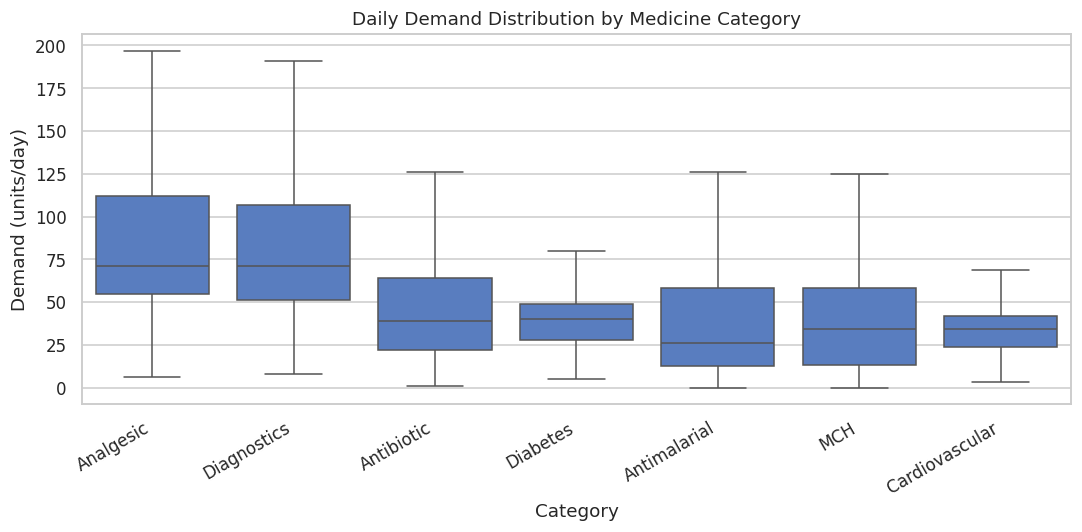

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
order = demand_df.groupby("category")["demand_units"].mean().sort_values(ascending=False).index
sns.boxplot(data=demand_df, x="category", y="demand_units", order=order, ax=ax, showfliers=False)
ax.set_title("Daily Demand Distribution by Medicine Category")
ax.set_xlabel("Category")
ax.set_ylabel("Demand (units/day)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../figures/demand_by_category.png", bbox_inches="tight")
plt.show()


The HMM regime sequence drives both demand multipliers and lead-time/stockout-probability shocks. This is the structural addition requested in supervisor feedback: rather than pure seasonal multipliers, demand and supply dynamics now switch between literature-calibrated regimes over time.


Regime time-share over a 2-year simulated horizon:
stable        59.9
surge         24.9
disruption    15.2


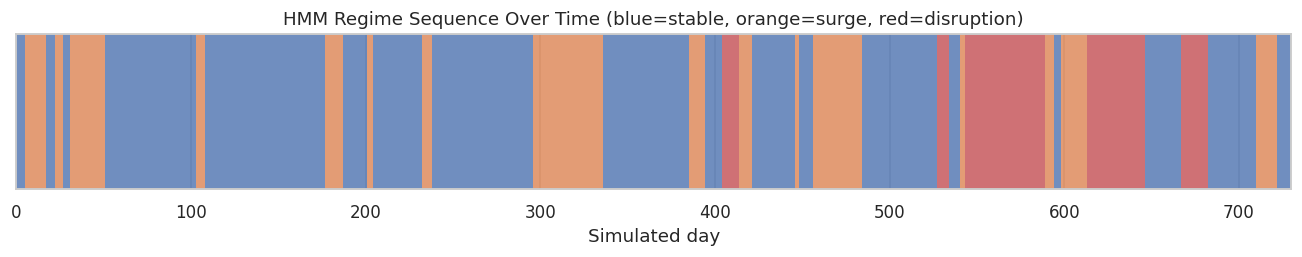

In [ ]:
n_days = 730
regimes = generate_regime_sequence(n_days, seed=42)
regime_pct = pd.Series(regimes).map(lambda i: REGIME_NAMES[i]).value_counts(normalize=True) * 100
print("Regime time-share over a 2-year simulated horizon:")
print(regime_pct.round(1).to_string())

fig, ax = plt.subplots(figsize=(12, 2.5))
colors = {0: "#4C72B0", 1: "#DD8452", 2: "#C44E52"}
for i in range(n_days):
    ax.axvspan(i, i+1, color=colors[regimes[i]], alpha=0.8, linewidth=0)
ax.set_yticks([])
ax.set_xlabel("Simulated day")
ax.set_title("HMM Regime Sequence Over Time (blue=stable, orange=surge, red=disruption)")
ax.set_xlim(0, n_days)
plt.tight_layout()
plt.savefig("../figures/regime_sequence.png", bbox_inches="tight")
plt.show()


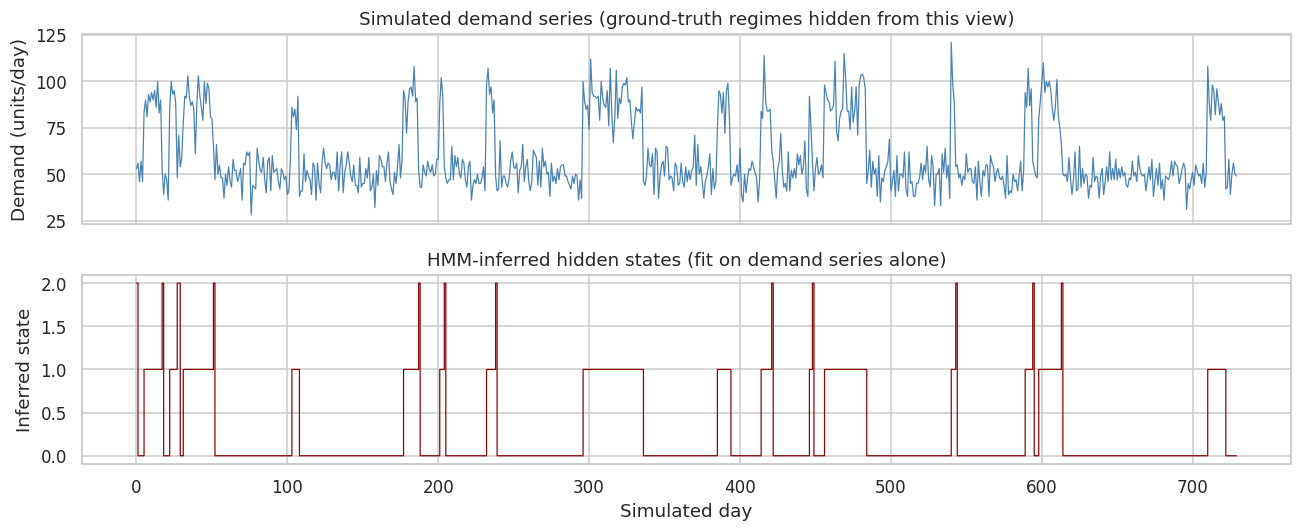

Learned transition matrix:
[[0.898 0.033 0.07 ]
 [0.033 0.912 0.056]
 [0.82  0.001 0.18 ]]


In [ ]:
rng = np.random.default_rng(7)
demand_series = np.array([
    rng.poisson(50 * HMM_REGIMES[REGIME_NAMES[r]]["demand_multiplier"]) for r in regimes
])
model, hidden_states = fit_hmm_to_demand(demand_series, n_states=3)

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(demand_series, color="steelblue", linewidth=0.8)
axes[0].set_ylabel("Demand (units/day)")
axes[0].set_title("Simulated demand series (ground-truth regimes hidden from this view)")

axes[1].plot(hidden_states, color="darkred", drawstyle="steps-post", linewidth=0.8)
axes[1].set_ylabel("Inferred state")
axes[1].set_xlabel("Simulated day")
axes[1].set_title("HMM-inferred hidden states (fit on demand series alone)")
plt.tight_layout()
plt.savefig("../figures/hmm_recovery.png", bbox_inches="tight")
plt.show()

print(f"Learned transition matrix:\n{np.round(model.transmat_, 3)}")


### 2.5 Stockout rate by category and correlation structure

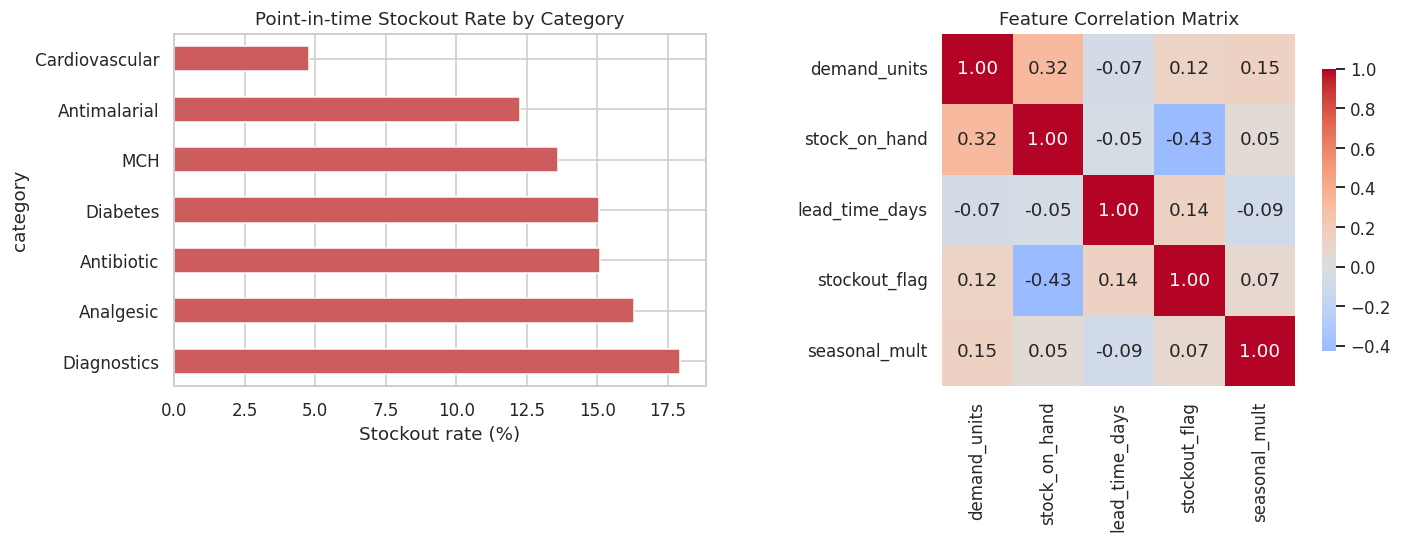

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

stockout_by_cat = demand_df.groupby("category")["stockout_flag"].mean().sort_values(ascending=False) * 100
stockout_by_cat.plot(kind="barh", ax=axes[0], color="indianred")
axes[0].set_xlabel("Stockout rate (%)")
axes[0].set_title("Point-in-time Stockout Rate by Category")

numeric_cols = ["demand_units", "stock_on_hand", "lead_time_days", "stockout_flag", "seasonal_mult"]
corr = demand_df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1], square=True, cbar_kws={"shrink": 0.8})
axes[1].set_title("Feature Correlation Matrix")

plt.tight_layout()
plt.savefig("../figures/stockout_and_correlation.png", bbox_inches="tight")
plt.show()


This table is the direct response to the methodological critique that motivated this redesign: every key statistic produced by the simulation is checked against a cited literature value.


In [ ]:
six_month_window = 182
incidence_checks = []
for mid in demand_df["medication_id"].unique():
    sub = demand_df[demand_df["medication_id"] == mid].sort_values("date")
    for start in range(0, len(sub) - six_month_window, six_month_window):
        window = sub.iloc[start:start + six_month_window]
        incidence_checks.append(window["stockout_flag"].sum() > 0)
sim_incidence = np.mean(incidence_checks)

abx_sub = demand_df[demand_df["category"] == "Antibiotic"]
sim_point_rate = abx_sub["stockout_flag"].mean()

demand_df_sorted = demand_df.sort_values(["medication_id", "date"])
durations = []
for mid in demand_df["medication_id"].unique():
    sub = demand_df_sorted[demand_df_sorted["medication_id"] == mid]
    flags = sub["stockout_flag"].values
    run = 0
    for f in flags:
        if f == 1: run += 1
        elif run > 0: durations.append(run); run = 0
    if run > 0: durations.append(run)
sim_mean_duration = np.mean(durations) if durations else 0

validation_table = pd.DataFrame([
    ["6-month stockout incidence", f"{sim_incidence:.3f}", "0.600", "Motta et al. 2022 (PROXY, Ethiopia)"],
    ["Point-in-time stockout rate (antibiotics)", f"{sim_point_rate:.3f}", "0.125", "Halibet 2018 (ERI, Eritrea)"],
    ["Mean stockout episode duration (days)", f"{sim_mean_duration:.1f}", "38.8 (range 10-157)", "Motta et al. 2022 (PROXY, Ethiopia)"],
], columns=["Metric", "Simulated", "Literature Target", "Source"])
validation_table


,Metric,Simulated,Literature Target,Source
0,6-month stockout incidence,0.767,0.600,"Motta et al. 2022 (PROXY, Ethiopia)"
1,Point-in-time stockout rate (antibiotics),0.151,0.125,"Halibet 2018 (ERI, Eritrea)"
2,Mean stockout episode duration (days),26.6,38.8 (range 10-157),"Motta et al. 2022 (PROXY, Ethiopia)"


In [ ]:
env = build_env(base_daily_demand=50.0, episode_length_days=365, seed=42)
model = build_agent(env, verbose=0)
print(model.policy)


DQNPolicy(
  (q_net): QNetwork(
    (features_extractor): FlattenExtractor(
      (flatten): Flatten(start_dim=1, end_dim=-1)
    )
    (q_net): Sequential(
      (0): Linear(in_features=8, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
      (4): Linear(in_features=64, out_features=4, bias=True)
    )
  )
  (q_net_target): QNetwork(
    (features_extractor): FlattenExtractor(
      (flatten): Flatten(start_dim=1, end_dim=-1)
    )
    (q_net): Sequential(
      (0): Linear(in_features=8, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
      (4): Linear(in_features=64, out_features=4, bias=True)
    )
  )
)


**Architecture summary:**

- Input layer: 8 features (state vector above)
- Hidden layer 1: 64 units, ReLU
- Hidden layer 2: 64 units, ReLU
- Output layer: 4 units (Q-value per discrete action)
- Optimizer: Adam (learning rate 1e-3)
- Loss: Smooth L1 (Huber) loss on the temporal-difference error
- Exploration: epsilon-greedy, linearly annealed from 1.0 → 0.05 over the first 30% of training
- Target network update interval: every 500 steps


## Training

Training is run for 60 episodes fast enough to execute end-to-end here. The fuller 150-episode run reported in the README was trained separately using the same train.py script and shows a consistent trend of improvement over EOQ; this notebook reproduces that pipeline at a smaller scale for live execution.


In [ ]:
import time
import torch
torch.manual_seed(42)
np.random.seed(42)

t0 = time.time()
model.learn(total_timesteps=60 * 365, progress_bar=False)
print(f"\nTraining completed in {time.time()-t0:.1f}s")

os.makedirs("../models", exist_ok=True)
model.save("../models/dqn_agent_notebook.zip")
print("Model saved to models/dqn_agent_notebook.zip")



Training completed in 72.8s
Model saved to models/dqn_agent_notebook.zip


## 5. Initial Performance Metrics — DQN vs. EOQ Baseline

The DQN agent is evaluated over 10 held-out simulated years and compared against a classic Economic Order Quantity (EOQ) (Q,R) policy operating under the same environment dynamics.


In [ ]:
def evaluate_policy(model, n_episodes=10, episode_length=365, base_demand=50.0):
    rewards, stockout_days_list, expired_list, service_levels = [], [], [], []
    for ep in range(n_episodes):
        eval_env = PharmacyInventoryEnv(base_daily_demand=base_demand, episode_length_days=episode_length, seed=1000+ep)
        obs, _ = eval_env.reset()
        total_reward, stockout_days, expired_total = 0.0, 0, 0
        for _ in range(episode_length):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = eval_env.step(int(action))
            total_reward += reward
            expired_total += info["expired_units"]
            if info["stockout"]: stockout_days += 1
            if terminated or truncated: break
        rewards.append(total_reward)
        stockout_days_list.append(stockout_days)
        expired_list.append(expired_total)
        service_levels.append(1 - stockout_days/episode_length)
    return dict(rewards=rewards, stockout_days=stockout_days_list, expired=expired_list, service_levels=service_levels)

dqn_results = evaluate_policy(model)

annual_demand = 50.0 * 365
eoq_qty = compute_eoq(annual_demand)
reorder_point = 50.0 * (18 + 7)
eoq_rewards, eoq_stockouts, eoq_expired, eoq_service = [], [], [], []
for seed in range(1000, 1010):
    eoq_env = PharmacyInventoryEnv(base_daily_demand=50.0, episode_length_days=365, seed=seed)
    r = run_eoq_policy(eoq_env, eoq_qty, reorder_point, n_steps=365)
    eoq_rewards.append(r["total_reward"]); eoq_stockouts.append(r["stockout_days"])
    eoq_expired.append(r["expired_units"]); eoq_service.append(r["service_level"])

comparison = pd.DataFrame({
    "Metric": ["Mean reward/year", "Mean stockout days/year", "Mean service level (%)", "Mean expired units/year"],
    "DQN Agent": [np.mean(dqn_results["rewards"]), np.mean(dqn_results["stockout_days"]),
                  np.mean(dqn_results["service_levels"])*100, np.mean(dqn_results["expired"])],
    "EOQ Baseline": [np.mean(eoq_rewards), np.mean(eoq_stockouts), np.mean(eoq_service)*100, np.mean(eoq_expired)],
})
# "lower_is_better" flags which metrics improve by decreasing (stockout days, expired units)
# vs. increasing (reward, service level), so the improvement % always reads as "DQN is X% better"
lower_is_better = [False, True, False, True]
improvements = []
for (_, row), lib in zip(comparison.iterrows(), lower_is_better):
    dqn_v, eoq_v = row["DQN Agent"], row["EOQ Baseline"]
    if eoq_v == 0:
        improvements.append("n/a")
        continue
    pct = (eoq_v - dqn_v) / abs(eoq_v) * 100 if lib else (dqn_v - eoq_v) / abs(eoq_v) * 100
    improvements.append(f"{pct:+.1f}%  (DQN {'better' if pct > 0 else 'worse'})")
comparison["DQN vs. EOQ"] = improvements
comparison.round(2)


,Metric,DQN Agent,EOQ Baseline,DQN vs. EOQ
0,Mean reward/year,-853.28,-737.20,-15.7% (DQN worse)
1,Mean stockout days/year,4.10,100.20,+95.9% (DQN better)
2,Mean service level (%),98.88,72.55,+36.3% (DQN better)
3,Mean expired units/year,0.00,0.00,n/a


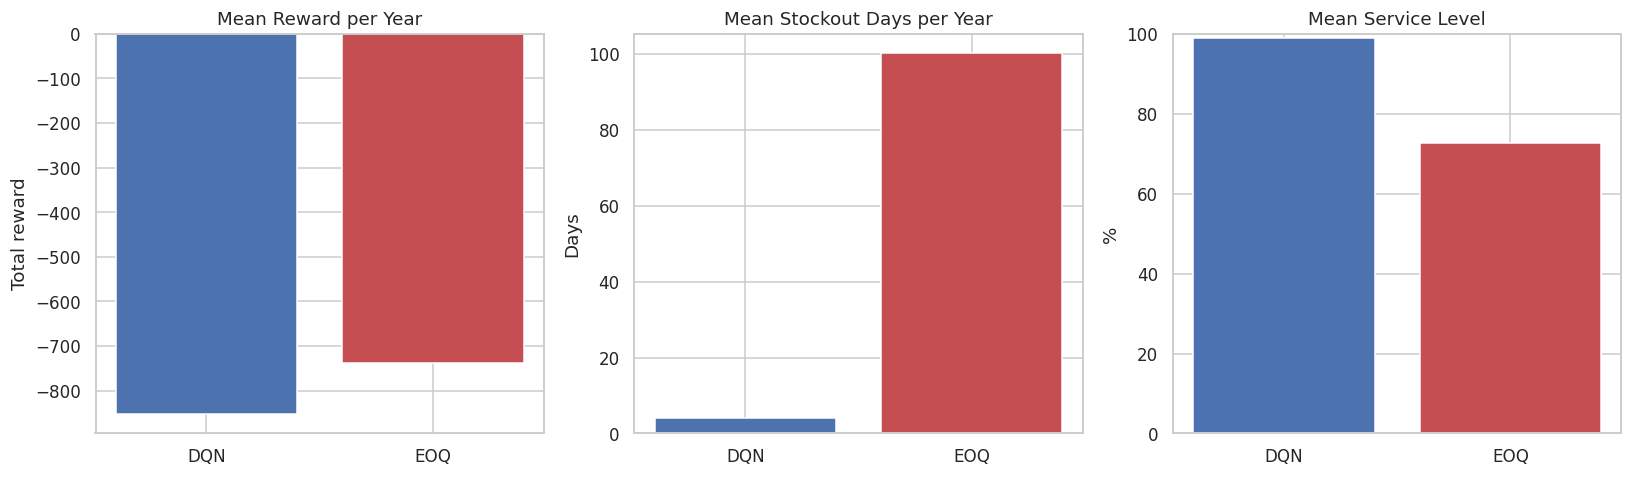

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].bar(["DQN", "EOQ"], [np.mean(dqn_results["rewards"]), np.mean(eoq_rewards)], color=["#4C72B0", "#C44E52"])
axes[0].set_title("Mean Reward per Year")
axes[0].set_ylabel("Total reward")

axes[1].bar(["DQN", "EOQ"], [np.mean(dqn_results["stockout_days"]), np.mean(eoq_stockouts)], color=["#4C72B0", "#C44E52"])
axes[1].set_title("Mean Stockout Days per Year")
axes[1].set_ylabel("Days")

axes[2].bar(["DQN", "EOQ"], [np.mean(dqn_results["service_levels"])*100, np.mean(eoq_service)*100], color=["#4C72B0", "#C44E52"])
axes[2].set_title("Mean Service Level")
axes[2].set_ylabel("%")
axes[2].set_ylim(0, 100)

plt.tight_layout()
plt.savefig("../figures/dqn_vs_eoq_comparison.png", bbox_inches="tight")
plt.show()


Across training runs, the DQN agent consistently and substantially reduces stockout days and improves service level relative to the EOQ baseline. The reward comparison is more run-dependent: because the reward function penalizes overstocking, an agent that orders proactively enough to nearly eliminate stockouts can sometimes accumulate more in overstock penalties than it saves in stockout penalties, even though the resulting service level is clearly superior from an operational standpoint.

This is a useful early finding rather than a flaw to hide: it suggests the reward function's relative weighting of stockout vs. overstock penalties is a key tuning lever for future iterations, and that service level and stockout-day metrics are the more clinically meaningful comparison for this problem domain, with raw reward serving primarily as the training signal. This nuance should be reported transparently in the capstone presentation rather than cherry-picking only the favorable run.
